<a href="https://colab.research.google.com/github/dex-mishra/ML/blob/main/First_Online_Book.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import kagglehub
path = kagglehub.dataset_download("sahilislam007/college-student-placement-factors-dataset")
import pandas as pd

100%|██████████| 108k/108k [00:00<00:00, 27.1MB/s]

Extracting files...


In [ ]:
import os

# List the contents of the downloaded directory
print(os.listdir(path))

['college_student_placement_dataset.csv']


In [ ]:
csv_file_name = 'college_student_placement_dataset.csv'
full_csv_path = os.path.join(path, csv_file_name)
df = pd.read_csv(full_csv_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [ ]:
df.describe()


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [ ]:
num_trains = df.iloc[:,1:]
num_trains.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No


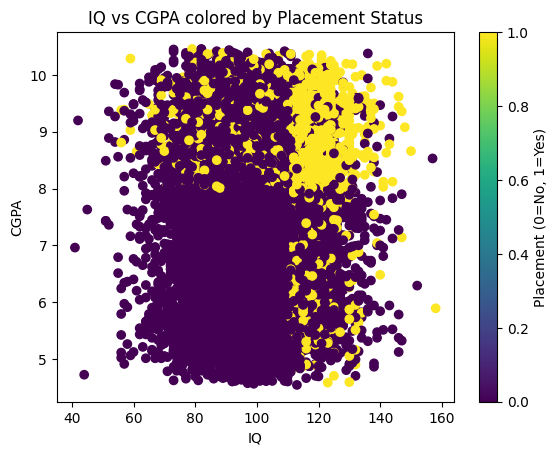

In [ ]:
import matplotlib.pyplot as plt

# Convert 'Placement' to numerical values (0 for 'No', 1 for 'Yes')
num_trains['Placement_Numeric'] = num_trains['Placement'].map({'No': 0, 'Yes': 1})
num_trains['Intern_Numeric'] = num_trains['Internship_Experience'].map({'No': 0, 'Yes': 1})
plt.scatter(num_trains['IQ'], num_trains['CGPA'], c=num_trains['Placement_Numeric'], cmap='viridis')
plt.xlabel('IQ')
plt.ylabel('CGPA')
plt.title('IQ vs CGPA colored by Placement Status')
plt.colorbar(label='Placement (0=No, 1=Yes)')
plt.show()

In [ ]:

num_trains.drop(columns=['Placement'], axis=1,inplace=True)
num_trains.drop(columns=['Internship_Experience'],axis=1, inplace=True)
num_trains.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement_Numeric,Intern_Numeric
0,107,6.61,6.28,8,8,8,4,0,0
1,97,5.52,5.37,8,7,8,0,0,0
2,109,5.36,5.83,9,3,1,1,0,0
3,122,5.47,5.75,6,1,6,1,0,1
4,96,7.91,7.69,7,8,10,2,0,0


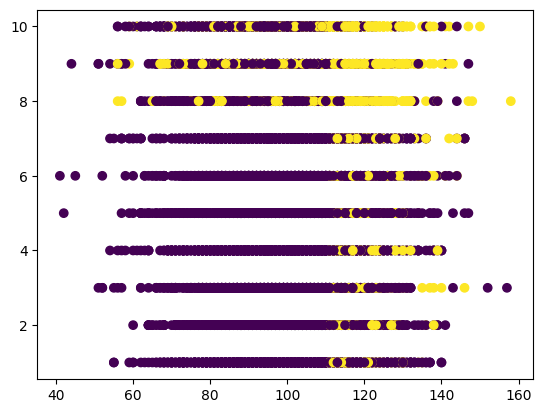

In [ ]:
plt.scatter(num_trains['IQ'], num_trains['Communication_Skills'], c=num_trains['Placement_Numeric'],cmap='viridis')

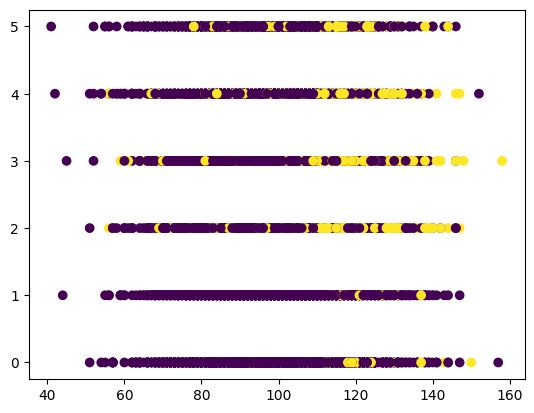

In [ ]:

plt.scatter(num_trains['IQ'], num_trains['Projects_Completed'], c=num_trains['Placement_Numeric'], cmap='viridis')

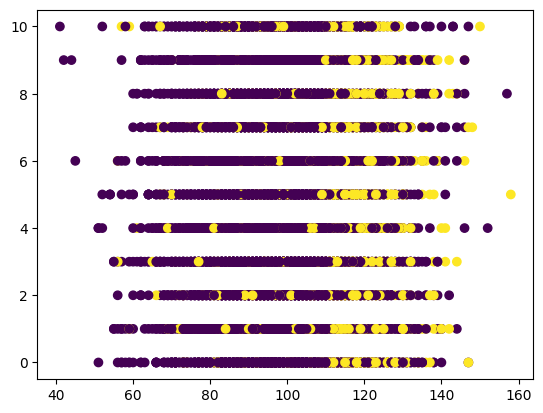

In [ ]:
plt.scatter(num_trains['IQ'], num_trains['Extra_Curricular_Score'], c=num_trains['Placement_Numeric'], cmap='viridis')

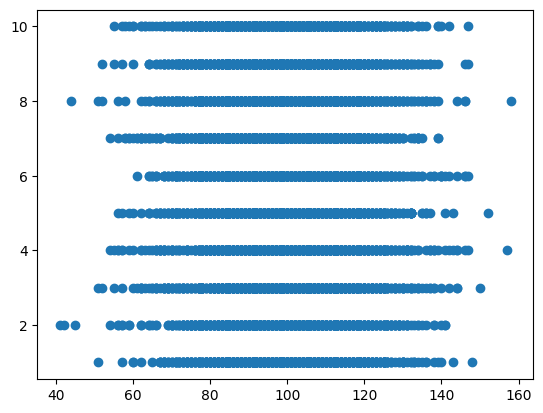

In [ ]:
plt.scatter(num_trains['IQ'], num_trains['Academic_Performance']c=num_trains['Placement'])



In [ ]:
cols = num_trains.columns.tolist()
# Remove 'Placement_Numeric' from its current position
cols.remove('Placement_Numeric')
# Add 'Placement_Numeric' to the end of the list
cols.append('Placement_Numeric')
# Reindex the DataFrame with the new column order
num_trains = num_trains[cols]

display(num_trains.head())

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Intern_Numeric,Placement_Numeric
0,107,6.61,6.28,8,8,8,4,0,0
1,97,5.52,5.37,8,7,8,0,0,0
2,109,5.36,5.83,9,3,1,1,0,0
3,122,5.47,5.75,6,1,6,1,1,0
4,96,7.91,7.69,7,8,10,2,0,0


In [ ]:
training = num_trains.iloc[:,:-1]
target = num_trains.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(training,target,test_size=0.2)

In [ ]:
x_train

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Intern_Numeric
3949,80,6.62,6.17,6,3,1,2,0
7959,94,9.75,9.58,8,0,2,3,1
6505,96,7.28,7.58,4,4,6,5,1
4577,127,8.03,8.13,4,8,10,0,0
89,107,9.37,9.85,8,7,1,5,1
...,...,...,...,...,...,...,...,...
2522,105,9.90,10.31,9,9,5,4,0
6575,117,8.15,8.24,9,7,8,1,1
7405,124,8.45,8.79,1,9,3,4,0
6516,125,9.60,9.15,8,6,3,1,0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
clf = LogisticRegression()
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.905
[[1624   65]
 [ 125  186]]


<Axes: >

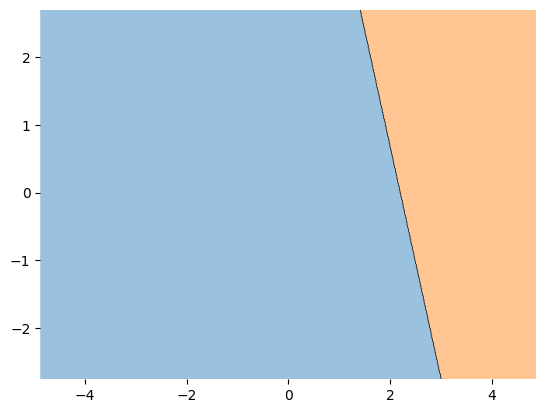

In [ ]:
from mlxtend.plotting import plot_decision_regions
import numpy as np

feature_index = [0,1]

# Calculate the mean of each feature in x_train
x_train_mean = np.mean(x_train, axis=0)

# Create a dictionary for filler_feature_values
# We need to fill values for all features except the ones in feature_index
filler_feature_values = {}
for i in range(x_train.shape[1]):
    if i not in feature_index:
        filler_feature_values[i] = x_train_mean[i]

plot_decision_regions(x_train, y_train.values, clf=clf, legend=2, feature_index=feature_index, filler_feature_values=filler_feature_values)


In [ ]:
import pickle
pickle.dump(clf, open('placement_model.pkl', 'wb'))